In [89]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
base_path = Path(".") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

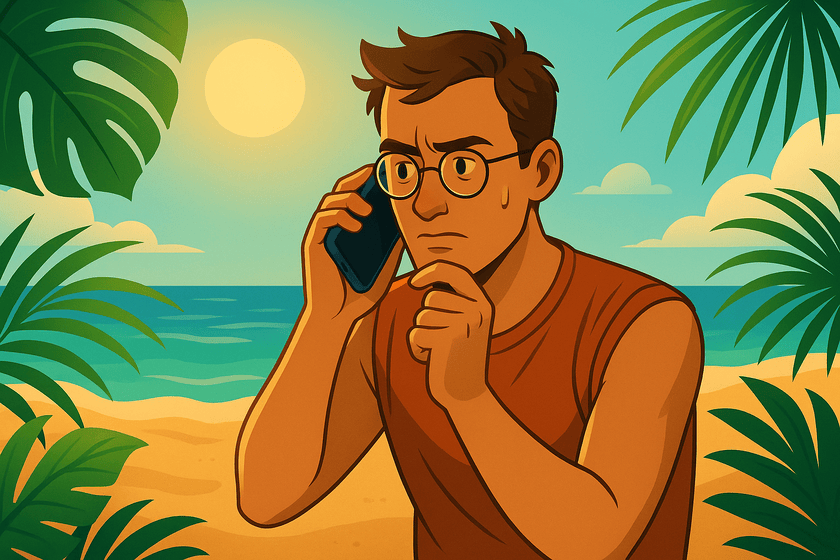

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania? **DONE**
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1) **DONE**
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3) **DONE**
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład) **DONE**
- Która zmienna oznacza predykowaną klasę? **DONE**
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1) **DONE**
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)
**DONE**

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1) **DONE**
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2) **IN PROGRESS**
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3) **DONE**
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych **DONE**
- Każda cecha powinna być zwizualizowana co najmniej raz. **DONE**
- Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4) **ALMOST DONE**
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków **ALMOST DONE**

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [91]:
titanic_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/titanic.csv', index_col='PassengerId')

In [92]:
titanic_df.Survived.value_counts(normalize=True)
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

- W kontekście zadania nie wszystkie kolumny są istotne, tutaj liczymy właściwie wyłącznie kwestię przeżycia, imię i nazwisko pasażera oraz ewentualnie płeć, wiek pasażera i kabina, w której się znajdował.
- W zbiorze tym brakujące wartości możemy sprawdzić w następujący sposób:

In [93]:
def get_percentage_missing(df, axis):
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_percentage = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_percentage[missing_rows_percentage > 0]

In [94]:
missing_columns = get_percentage_missing(titanic_df, axis=0)
missing_columns

,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


Jak zatem możemy zauważyć, w przypadku kolumn związanych z wiekiem pasażerów, ich opłatą wniesioną za rejs, kabinami, w których przebywali i w mniejszym stopniu informacjami o miejscu, z którego wypłynęli występują brakujące wartości. Pomimo że opłata wniesiona za rejs i miejsca wyruszenia nie przydają się w kontekście zadania, warto uzupełnić kolumny brakującymi wartościami - zrobimy to na podstawie rozkładu ich wartości:

In [95]:
def get_column_distribution(df, column):
  return df[column].value_counts(normalize=True)

In [96]:
# Kolumna "Age"
age_count_prob = get_column_distribution(titanic_df, 'Age')
age_count_prob
# Kolumna "Fare"
fare_count_prob = get_column_distribution(titanic_df, 'Fare')
fare_count_prob
# Kolumna "Cabin"
cabin_count_prob = get_column_distribution(titanic_df, 'Cabin')
cabin_count_prob
# Kolumna "Embarked"
embarked_count_prob = get_column_distribution(titanic_df, 'Embarked')
embarked_count_prob

,proportion
Embarked,
S,0.724409
C,0.188976
Q,0.086614


Zanim zaczniemy tworzyć wizualizacje oraz obliczać statystyki dla danych, sprawdzamy typy danych w kolumnach:

In [97]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


W większości przypadków nasze typy danych są poprawne. Jedynie dla kolumny 'Age' mamy typ float64, który wskazuje na to, że wiek w latach liczy się w ułamkach, czego się zazwyczaj nie robi.

In [98]:
def plot_numeric_histogram(df, column_name):

    data = df[column_name].dropna()
    mean_val = data.mean()
    median_val = data.median()

    plt.figure(figsize=(6, 4))
    plt.hist(data, bins=30, color='steelblue', edgecolor='black')
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

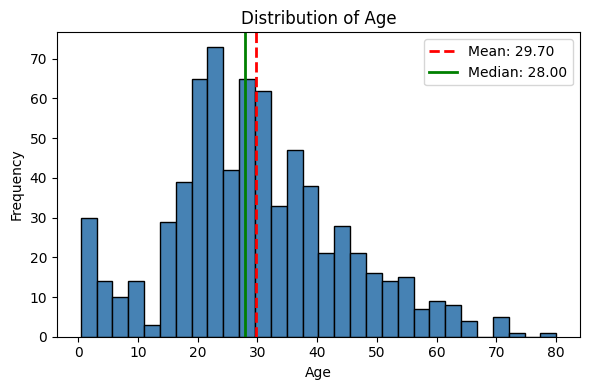

In [99]:
# Na przykładzie wieku pasażerów
plot_numeric_histogram(titanic_df, 'Age')

Można powiedzieć, że powyższy rozkład jest zbliżony do **rozkładu normalnego** z pewnymi cechami rozkładu **asymetrycznego**. Wynika to z tego, że:
- większość wartości skupia się w przedziale 15-40,
- kształtem wykresu jest nieco asymetryczny dzwon, wykres jest nieco przesunięty,
- wartości bardzo niskie bądź bardzo wysokie są rrzadsze niż z określonego przedziału.



Przy pomocy wykresu punktowego Scatterplot sprawdzimy związek między wiekiem a, kolejno: płcią, przeżyciem osoby oraz ewentualnie klasą podróży:

In [100]:
def scatterplot(df, column_name, y):
  """
    Plots a scatterplot between the sex and survived.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The age column to plot against the survived column.
        y (str): the survived column
    Returns:
        None. Displays the scatterplot.
  """
  plt.figure(figsize=(6, 4))
  sns.scatterplot(data=df, x=column_name, y=y, color='darkorange', alpha=0.6)
  plt.title(f'{column_name} vs {y}')
  plt.xlabel(column_name)
  plt.ylabel(y)
  plt.tight_layout()
  plt.show()

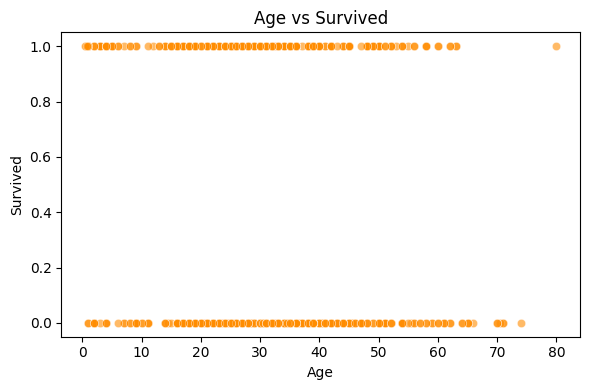

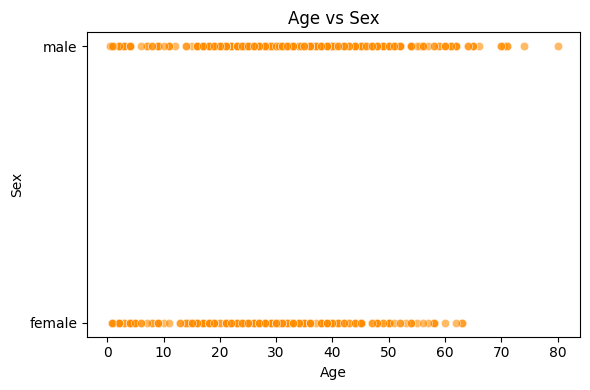

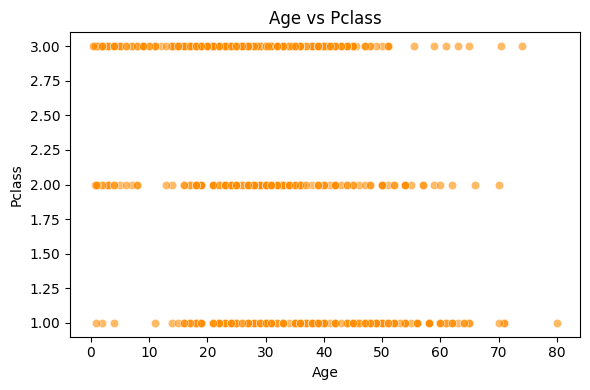

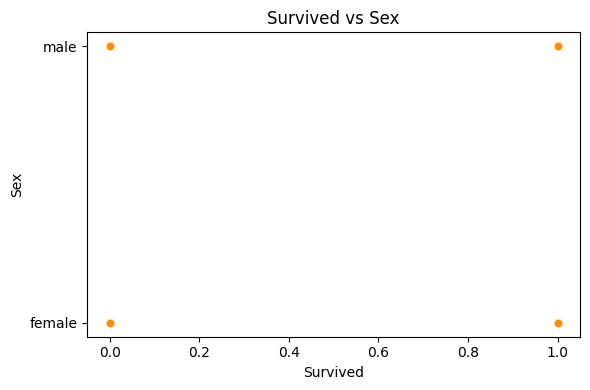

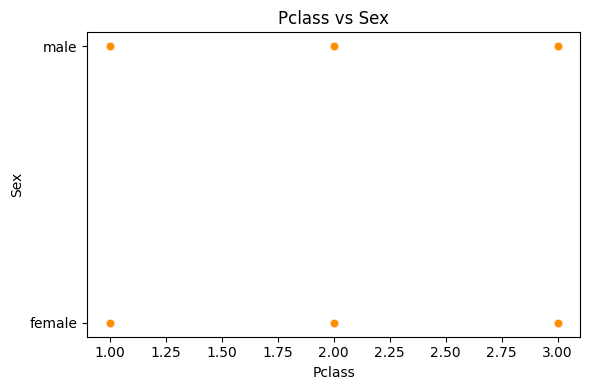

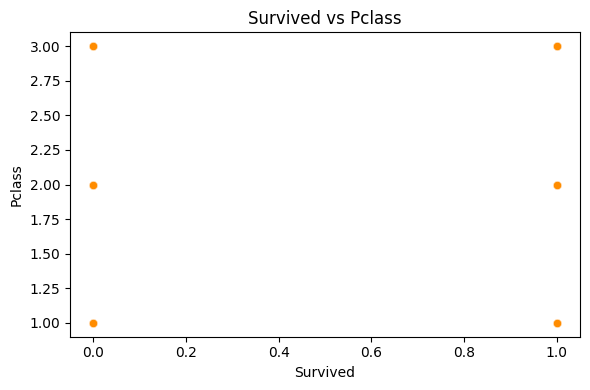

In [101]:
scatterplot(titanic_df, 'Age','Survived')
scatterplot(titanic_df, "Age", "Sex")
scatterplot(titanic_df, "Age", "Pclass")
scatterplot(titanic_df, "Survived","Sex")
scatterplot(titanic_df, "Pclass","Sex")
scatterplot(titanic_df, "Survived", "Pclass")


Poprzez wizualizację "scatterplotową" zależności między trzema kolumnami powyżej udało nam się wywnioskować kilka rzeczy:
- podczas rejsu (przynajmniej tak wynika z wizualizacji na wykresie) na statku było więcej mężczyzn niż kobiet i byli oni bardziej zróżnicowani wiekowo - kilku z nich było nawet w wieku około 70-80 lat,
- wśród pasażerów więcej osób mogło nie przeżyć - wśród nich były osoby w wieku około 70 lat,
- pierwsza i trzecia klasa były najbardziej obłożone przez pasażerów, a druga najmniej, dodatkowo w pierwszej klasie było najwięcej osób powyżej 60 roku życia.

Szczególną uwagę zwraca osoba w wieku około 80 lat, która, jak wynika z wykresów, była mężczyzną z pierwszej klasy i przeżyła katastrofę.

Niestety powiązania między płcią i przeżyciem, płcią i klasą podróży oraz przeżyciem i klasą podróży nie pozwala nam wyciągnąć większych wniosków ze względu na równomierne ułożenie punktów po obu stronach wykresów.


Być może to wskazuje na zmienną wieku jako predykowaną klasę. Pomimo tego inne zmienne również mają istotne znaczenie w interakcjach i potrzebne są przy dalszym modelowaniu.

W kwestii zmiennych (kolumn w tabeli) można podsumować, że:
- jedną ze zmiennych predykowanych jest zmienna "Age",
- zmiennymi numerycznymi są: "Age", "SibSp", "Parch", "Fare",
- zmiennymi kategorialnymi są: "Survived", "Ticket", "Cabin", "Pclass", "Sex", "Name", "Embarked"

Sprawdzimy teraz, jakie są rozkłady poszczególnych zmiennych. Użyjemy do tego wcześniej utworzonej funkcji
tworzącej histogram numeryczny i kategorialny (plot_category_histogram).

Dodatkowo będziemy musieli zakodować wartości kategorialne - przy generowaniu rozkładu dobierzemy odpowiedni sposób dla każdej z nich.

Po każdym wygenerowanym rozkładzie
sprawdzimy także występowanie możliwych wartości skrajnych (odstających, inaczej "outlierów").

Dla wieku już wcześniej określiliśmy, że rozkład jest **rozkładem normalnym** z cechami **asymetrycznymi**:

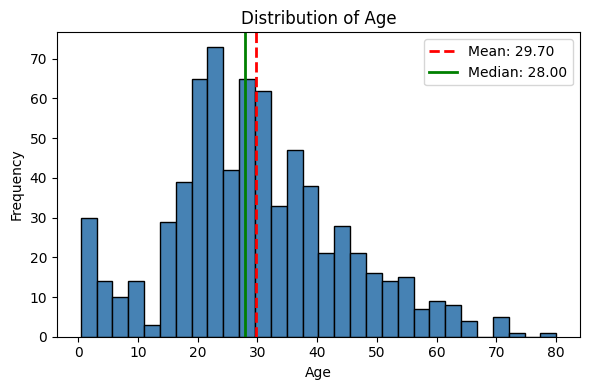

In [102]:
plot_numeric_histogram(titanic_df, 'Age')

Występowanie skrajnych wartości (outlierów) sprawdzimy przy pomocy funkcji **boxplot** (wykresu pudełkowego):

In [103]:
def boxplot(df, column_name):
    """
    Displays a boxplot of the choosen column to show its distribution.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='lightgreen') # as you can see, you can use sns and plt at the same time
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)

    plt.show()

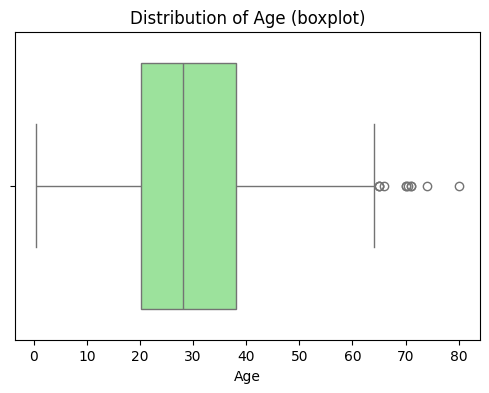

In [104]:
boxplot(titanic_df, "Age")

Zauważamy, że istnieją pewne wartości skrajne (pokazane jako okręgi). Wartości wieku między 65-80 lat były najrzadsze ze wszystkich i nie zostały uwzględnione w "wąsach" oraz w głównym zbiorze danych - w medianie między kwartylami.

W dalszej kolejności sprawdzimy rozkłady i wykresy pudełkowe innych zmiennych numerycznych:

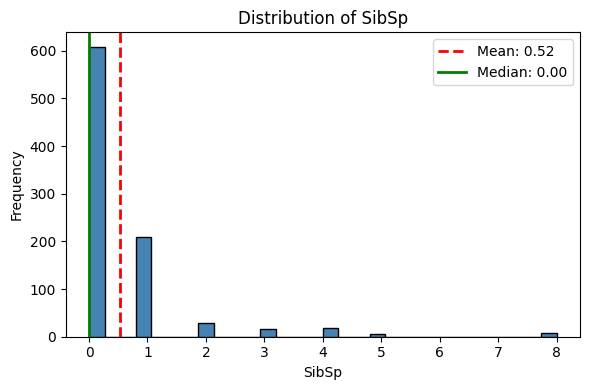

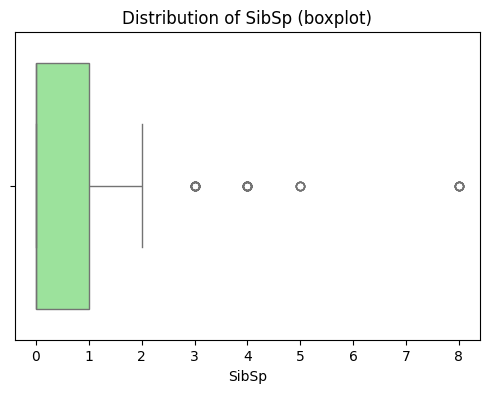

In [105]:
plot_numeric_histogram(titanic_df, 'SibSp')
boxplot(titanic_df, "SibSp")

W tym przypadku również możemy zauważyć występowanie rozkładu asymetrycznego - skośnego prawostronnie - bowiem średnia liczba występuje na wykresie po prawej stronie, co oznacza, że najwięcej pasażerów nie posiadało w ogóle rodzeństwa/małżonków.

Występują tutaj także skrajne wartości - widoczne są przypadki posiadania 3, 4, 5 i 8 rodzeństwa/małżonków kompletnie poza "pudełkiem", które jest maksymalnie przesunięte na lewo.

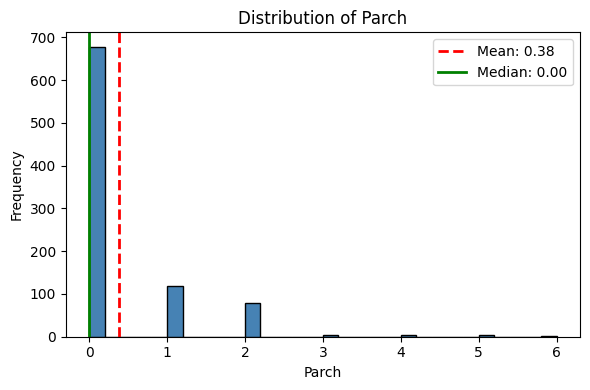

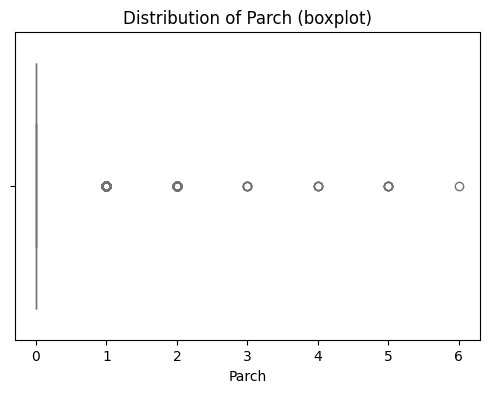

In [106]:
plot_numeric_histogram(titanic_df, 'Parch')
boxplot(titanic_df, "Parch")

Podobny rozkład danych - skośny prawostronnie - jest widoczny przy liczbie rodziców i dzieci - również zdecydowana większość nie posiadała ich (przynajmniej podczas pobytu na pokładzie).

Wykres pudełkowy jest niemal niewidoczny w tym przypadku. Wartości skrajne (1-6 rodziców/dzieci) są widoczne praktycznie na całym wykresie.

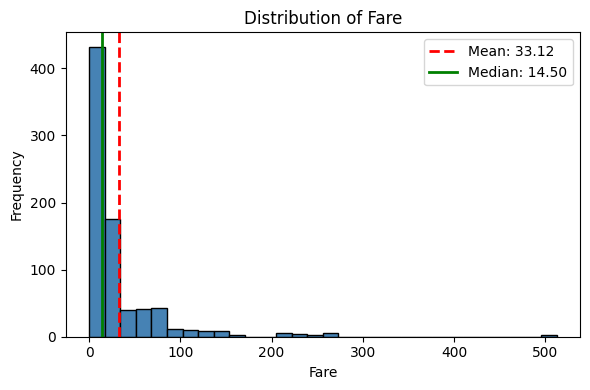

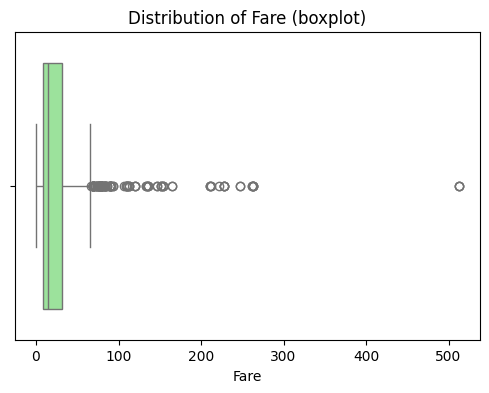

In [107]:
plot_numeric_histogram(titanic_df, "Fare")
boxplot(titanic_df, "Fare")

Dla opłaty wniesionej za rejs rozkład jest także asymetryczny (skośny prawostronnie) - jak widać cena biletu dla niektórych pasażerów była dosyć niska.
Wykres pudełkowy jest trochę bardziej widoczny po lewej stronie układu. Skrajnych wartości jest dosyć sporo w tym przypadku - najbardziej skrajną jest wartość nieco powyżej 500.

Funkcja tworząca histogram kategoryczny wygląda następująco:

In [108]:
def plot_categorical_column(df, column_name):
    """
    Plots a bar chart for the specified categorical column.
    Parameters:
        df (pandas.DataFrame): The DataFrame containing the data.
        column_name (str): The name of the categorical column to plot.
    Returns:
        None. Displays the bar chart.
    """

    # count occurrences of each category
    counts = df[column_name].value_counts()

    plt.figure(figsize=(6, 4))
    counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.show()

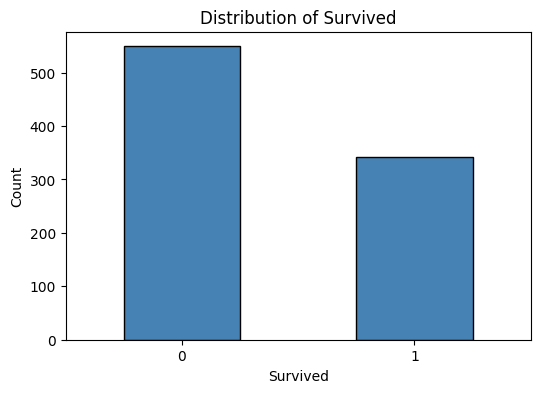

In [109]:
plot_categorical_column(titanic_df, 'Survived')

Wykres zmiennej "Survived" nie ma kształtu rozkładu normalnego, a skośny (konkretnie skośny prawostronnie). Większość wartości skupia się przy niższej wartości (czyli w tym przypadku większość osób nie przeżyła katastrofy).  

O rozkładzie możemy powiedzieć, że:
- ilość osób, które nie przeżyły była większa niż ocaleli z katastrofy - tak jak przewidzieliśmy...
- łączna liczba pasażerów mogła poza tym wynosić około 900.

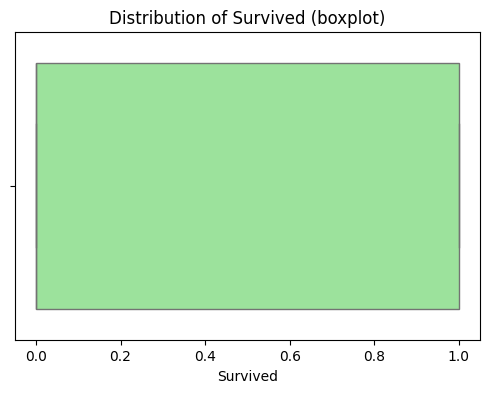

In [110]:
boxplot(titanic_df, "Survived")

W przypadku wartości określających, czy dany pasażer przeżył katastrofę, nie mamy obecnych żadnych wartości skrajnych - właściwie wszystkie wartości znajdują się w obszarze mediany.

Jako że w przypadku "Survived" mamy tylko dwie możliwe kategorie: ocalenie i śmierć, zastosujemy kodowanie binarne:

In [111]:
titanic_df.Survived.unique()
titanic_df['Survived'] = titanic_df.Survived.map({'No': 0, 'Yes': 1})
titanic_df['Survived'].value_counts()

,count
Survived,


Dla wartości kategorycznej jako płci zastosujemy kodowanie z etykietami (labeled):

In [112]:
# 0 i 1 to odpowiednio identyfikatory płci męskiej i żeńskiej
labels = titanic_df.Sex.unique()
labels_mapping = {
    k: i for i, k in enumerate(labels.tolist())
}
titanic_df['label'] = titanic_df.Sex.apply(lambda x: labels_mapping[x])
titanic_df['label']

,label
PassengerId,
1,0
2,1
3,1
4,1
5,0
...,...
887,0
888,1
889,1


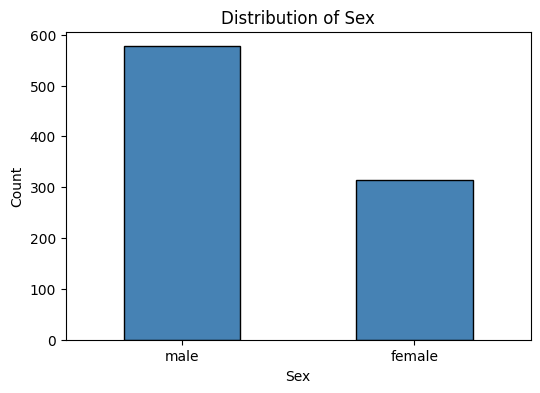

In [113]:
plot_categorical_column(titanic_df, "Sex")

Wykres zmiennej "Sex" również nie ma kształtu rozkładu normalnego. Tutaj również jest grubo skośnośny prawostronnie, natomiast mając dwie wartości o rozkładzie można mało powiedzieć.

Zauważyć możemy na pewno, że na statku było więcej mężczyzn niż kobiet...

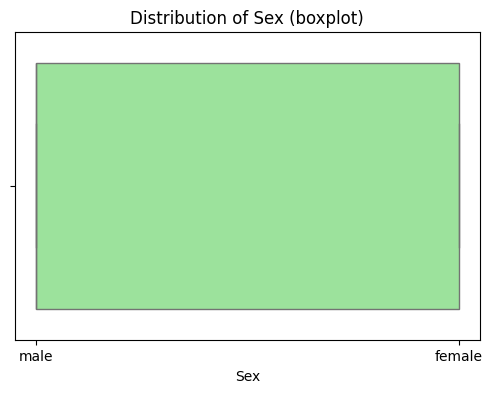

In [114]:
boxplot(titanic_df, "Sex")

Z wartościami skrajnymi dla płci jest podobnie jak w przypadku przeżycia - nie widać właściwie żadnych "outlierów".

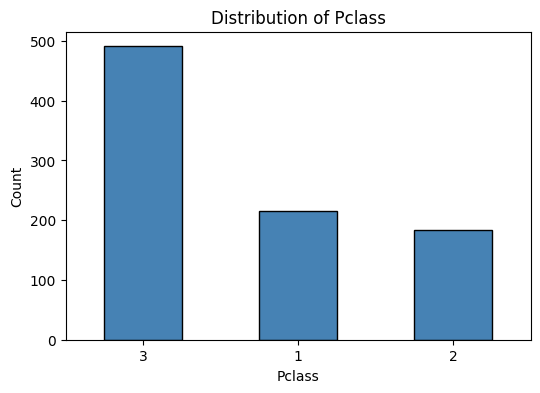

In [115]:
plot_categorical_column(titanic_df, "Pclass")

Ten wykres także nie ma kształtu rozkładu normalnego, a skośnego prawostronnie.

Możemy zauważyć, że najwięcej osób było w klasie 3, a najmniej w 1 i 2, z czego w 1 niewiele więcej niż w 2...

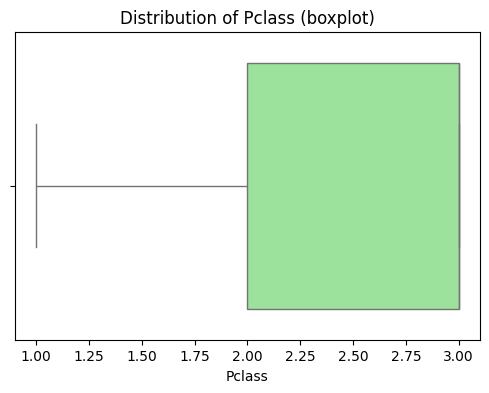

In [116]:
boxplot(titanic_df, "Pclass")

Tutaj również nie mamy obecnych żadnych wartości skrajnych.

Można jedynie zauważyć, że wykres (tj. główna jego część z medianą i kwartylami) został przesunięty maksymalnie w prawą stronę, zostawiając jeden (lewy) "wąs" widoczny.

W przypadku klasy podróży, ponieważ mamy kilka wartości odnoszących się do tego samego, ale jednak będacymi inne pod względem numeru (klasy podróży) możemy zastosować kodowanie porządkowe (Ordinal):

In [117]:
mapping = {
    '1st_class': 1,
    '2nd_class': 2,
    '3rd_class': 3
}
titanic_df['Pclass'] = titanic_df['Pclass'].map(mapping)
titanic_df.Pclass.value_counts()

,count
Pclass,


Dla wartości kategorycznej dotyczącej imienia i nazwiska możemy zastosować gorące/rzadkie kodowanie (One-hot):

In [118]:
names_count = titanic_df.Name.value_counts()
top_5_names = names_count.nlargest(n=5)
top_5_names

is_in_top_5_names = titanic_df.Name.isin(top_5_names.index)
titanic_df.loc[:, 'Name'] = titanic_df.Name.where(is_in_top_5_names, 'Other')
titanic_df.Name.value_counts()

one_hot_encoded_names = pd.get_dummies(data=titanic_df.Name, prefix='Name', columns=['Name'], dtype=np.int32)
titanic_df.head(n=1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,label
PassengerId,,,,,,,,,,,,
1,NaN,NaN,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,0


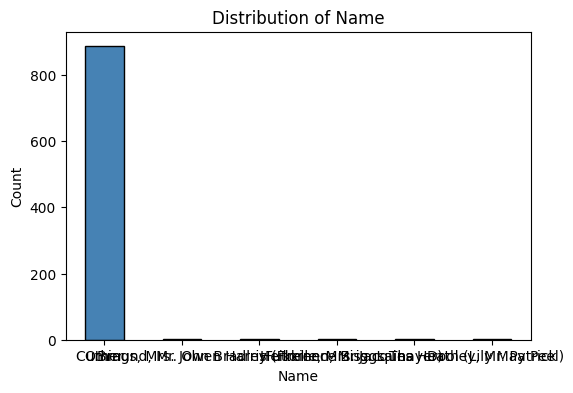

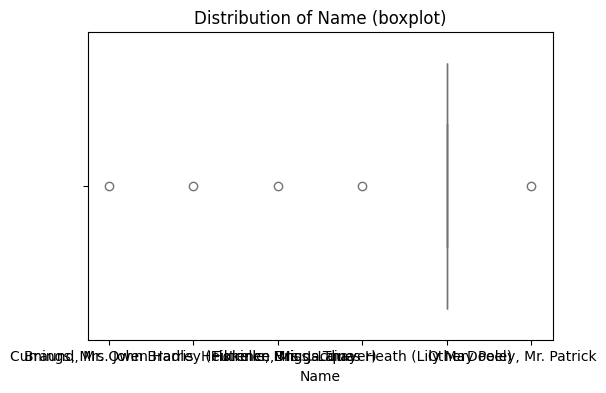

In [119]:
plot_categorical_column(titanic_df, "Name")
boxplot(titanic_df, "Name")

Wykres rozkładu dla imienia i nazwiska pasażerów pojawił się po samej lewej stronie. Z kolei wykres pudełkowy zawiera wartości skrajne - sam wykres jest dosyć mały i mało widoczny, a po obu stronach są wartości skrajne.

W przypadku miejsca wyruszenia, ponieważ mamy kilka wartości odnoszących się do zupełnie innych miejsc,możemy zastosować kodowanie porządkowe (Ordinal):

In [120]:
mapping = {
    'S': 1,
    'C': 2,
    'Q': 3
}
titanic_df['Embarked'] = titanic_df['Embarked'].map(mapping)
titanic_df.Embarked.value_counts()

,count
Embarked,
1.0,644
2.0,168
3.0,77


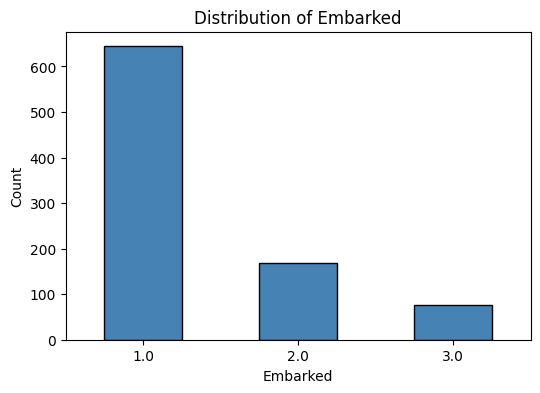

In [121]:
plot_categorical_column(titanic_df, "Embarked")

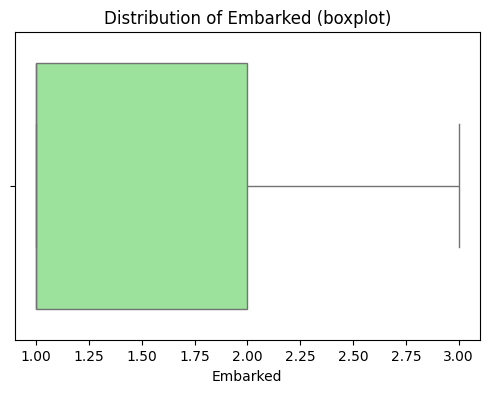

In [122]:
boxplot(titanic_df, "Embarked")

Wykres dla portu, z którego pasażerowie odpłynęli ma również rozkład skośny prawostronny - najwięcej osób wyruszyło z portu w Southampton.

Z kolei wykres pudełkowy został przesunięty (wraz z medianą i kwartylami) maksymalnie w lewą stronę, zostawiając prawy "wąs" w pełni widoczny. Także tu nie ma skrajnych wartości.

**Dodatkowo dla numeru biletu i kabiny:**

In [123]:
ticket_count = titanic_df.Ticket.value_counts()
top_5_tickets = ticket_count.nlargest(n=5)
top_5_tickets

is_in_top_5_tickets = titanic_df.Ticket.isin(top_5_tickets.index)
titanic_df.loc[:, 'Ticket'] = titanic_df.Ticket.where(is_in_top_5_tickets, 'Other')
titanic_df.Ticket.value_counts()

one_hot_encoded_ticket = pd.get_dummies(data=titanic_df.Ticket, prefix='Ticket', columns=['Ticket'], dtype=np.int32)
titanic_df.head(n=1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,label
PassengerId,,,,,,,,,,,,
1,NaN,NaN,"Braund, Mr. Owen Harris",male,22.0,1,0,Other,7.25,NaN,1.0,0


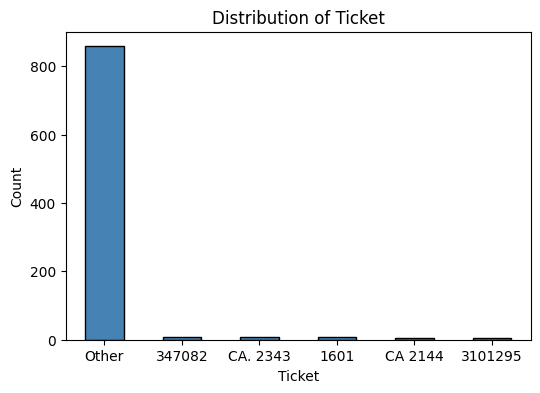

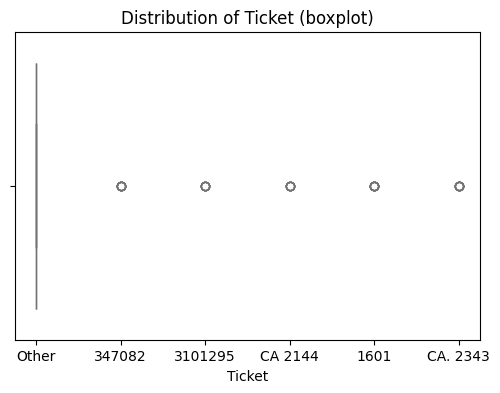

In [124]:
plot_categorical_column(titanic_df, "Ticket")
boxplot(titanic_df, "Ticket")

Rozkład jest skośny prawostronnie i widać skrajne wartości oraz mało widoczny wykres pudełkowy po lewej stronie.

In [125]:
cabin_count = titanic_df.Cabin.value_counts()
top_5_cabins = cabin_count.nlargest(n=5)
top_5_cabins

is_in_top_5_cabins = titanic_df.Cabin.isin(top_5_cabins.index)
titanic_df.loc[:, 'Cabin'] = titanic_df.Cabin.where(is_in_top_5_cabins, 'Other')
titanic_df.Cabin.value_counts()

one_hot_encoded_cabin = pd.get_dummies(data=titanic_df.Cabin, prefix='Cabin', columns=['Cabin'], dtype=np.int32)
titanic_df.head(n=1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,label
PassengerId,,,,,,,,,,,,
1,NaN,NaN,"Braund, Mr. Owen Harris",male,22.0,1,0,Other,7.25,Other,1.0,0


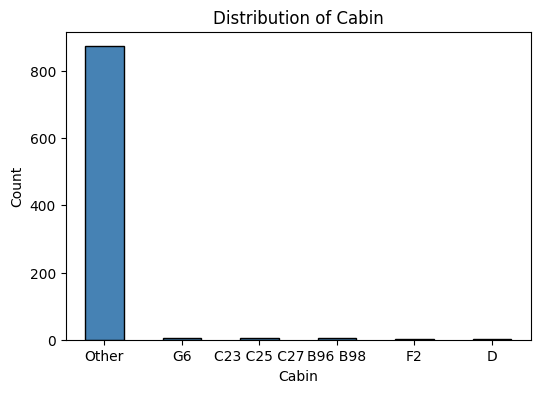

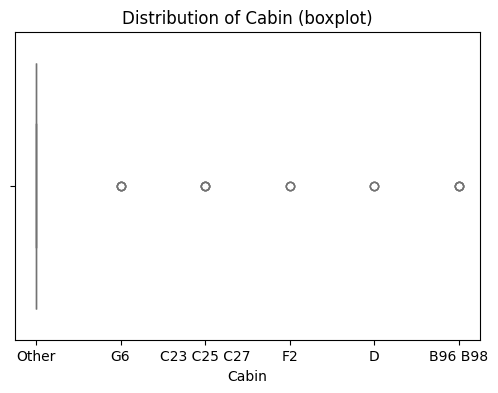

In [126]:
plot_categorical_column(titanic_df, "Cabin")
boxplot(titanic_df, "Cabin")

Tutaj także nie ma rozkładu normalnego - jest skośny prawostronnie. Outliery są widoczne od lewej strony do prawej, a po lewej stronie jest ledwo widoczny wykres pudełkowy.

No dobrze, przeanalizowaliśmy rozkłady normalne i występowanie "outlierów" dla wszystkich możliwych zmiennych.

Jednak jak zauważyliśmy na początku, nie wszystkie zmienne - a więc w związku z tym również rozkłady - będą dla nas istotne w kontekście zadania i nie wszystkie będą nam potrzebne do nauki modelu do klasyfikacji pasażerów jako ofiar bądź ocalałych.

Z tych samych powodów możemy wywnioskować, że nie opłaca się wizualizować parami cech w celu wykrycia zależności między wszystkimi możliwymi cechami.